In [1]:
import os, sys
os.chdir(os.path.join(os.path.dirname(os.path.abspath("__file__")), ".."))  # ensure project root
sys.path.insert(0, os.getcwd())
from src import model
import matplotlib.pyplot as plt
import gurobipy
import pandas as pd
import yaml
import numpy as np
import os
import pypsa

In [2]:
%%capture
# run models with different max caps
#current emissions aprox. 60 000l*2.65kg CO2e/l= 159t CO2e (with installed capacities?)
#problem with implementation of Co2 contraints. constraints > 20t always lead in 100% diesel?!? double check!
initial_emission = 75
decrement_step = 5
diesel_price = 0.12

emission_models = {}
for emission in range(initial_emission, -5, -decrement_step):
    emission_models[f"emissions_model_{emission}"] = model.main(emission, diesel_price)


save all files to local folder

In [3]:
folder_name = "models_existing_co2"
if not os.path.exists(folder_name):
    os.makedirs(folder_name)
initial_emission = 100
decrement_step = 5
for model_name, network in emission_models.items():
    print(model_name)
    print(network)
    filename = os.path.join(folder_name, f"{model_name}.nc")  # For NetCDF format
    # Assuming 'model_instance' is a PyPSA Network object
    network.export_to_netcdf(filename)

emissions_model_75
PyPSA Network
Components:
 - Bus: 5
 - Carrier: 6
 - Generator: 11
 - GlobalConstraint: 1
 - Link: 8
 - Load: 2
 - Store: 5
Snapshots: 8760
emissions_model_70
PyPSA Network
Components:
 - Bus: 5
 - Carrier: 6
 - Generator: 11
 - GlobalConstraint: 1
 - Link: 8
 - Load: 2
 - Store: 5
Snapshots: 8760
emissions_model_65
PyPSA Network
Components:
 - Bus: 5
 - Carrier: 6
 - Generator: 11
 - GlobalConstraint: 1
 - Link: 8
 - Load: 2
 - Store: 5
Snapshots: 8760
emissions_model_60
PyPSA Network
Components:
 - Bus: 5
 - Carrier: 6
 - Generator: 11
 - GlobalConstraint: 1
 - Link: 8
 - Load: 2
 - Store: 5
Snapshots: 8760
emissions_model_55
PyPSA Network
Components:
 - Bus: 5
 - Carrier: 6
 - Generator: 11
 - GlobalConstraint: 1
 - Link: 8
 - Load: 2
 - Store: 5
Snapshots: 8760
emissions_model_50
PyPSA Network
Components:
 - Bus: 5
 - Carrier: 6
 - Generator: 11
 - GlobalConstraint: 1
 - Link: 8
 - Load: 2
 - Store: 5
Snapshots: 8760
emissions_model_45
PyPSA Network
Components:
 

load all models

In [4]:

# folder_name = "models_scratch_co2"
# emission_models = {}

# for filename in os.listdir(folder_name):
#     if filename.endswith(".nc"):
#         file_path = os.path.join(folder_name, filename)
#         model_instance = pypsa.Network(file_path)
#         model_name = os.path.splitext(filename)[0]
#         emission_models[model_name] = model_instance

# print("Models loaded into the dictionary:")#verfication that it has loaded it as desired 
# for model_name in emission_models:
#     print(model_name)

load config file

In [5]:
try:
    with open('config.yml', 'r') as file:
        config = yaml.safe_load(file)
        print(config)
except Exception as e:
    print(f"Error reading YAML file: {e}")

{'costs': {'USD_to_EUR': 0.84, 'year': 2030, 'discountrate': 0.06, 'lifetime': 25}, 'storage': {'thermal_enabled': True, 'max_hours': {'battery': 6, 'H2': 10}}, 'wind': {'turbines': ['V47']}, 'system': {'heat_enabled': True}, 'snapshots': {'start': datetime.datetime(2015, 1, 1, 0, 0), 'end': datetime.datetime(2015, 12, 31, 23, 0), 'resolution': '1h'}, 'solving': {'solver': 'gurobi', 'options': {'solver': 'choose', 'run_crossover': 'off', 'threads': 4}}}


In [6]:
emission_levels = []
lcoe_values = []
generation_data = {
    "hydrogen": [],
    "wind": [],
    "solar": [],
    "heat pump": [],
    "diesel": []
}

print(generation_data.keys())

for name, network in emission_models.items():
    emission_level = int(name.split('_')[-1])
    emission_levels.append(emission_level)

    
    for carrier in generation_data.keys():
        carrier_generators = network.generators.index[network.generators.carrier == carrier]
        generation = network.generators_t.p[carrier_generators].sum().sum()  # Sum over both time and generators
        generation_data[carrier].append(generation)

generation_df = pd.DataFrame(generation_data, index=emission_levels)

print(generation_data)
print(emission_levels)

dict_keys(['hydrogen', 'wind', 'solar', 'heat pump', 'diesel'])
{'hydrogen': [np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0)], 'wind': [np.float64(232298.91557596822), np.float64(231953.06271382858), np.float64(231905.65735269006), np.float64(234662.94953425563), np.float64(234426.12863699184), np.float64(235845.39945068274), np.float64(232880.00254394123), np.float64(240822.31422561427), np.float64(261245.86601183377), np.float64(281622.7513816786), np.float64(306150.80522243003), np.float64(332116.03895735205), np.float64(359533.1299684266), np.float64(375228.52449097164), np.float64(410228.8297817673), np.float64(426527.1026810907)], 'solar': [np.float64(176695.50453904958), np.float64(181196.8579449188), np.float64(180993.0829558574), np.float64(177060.926747248

compute the LCOE for all systems

In [9]:
discount_rate=0.06
overall_lcoe=[]
for model_name, network in emission_models.items():
    exchange_rate=11.92,
    generators = network.generators
    generators_t = network.generators_t
    marginal_diesel= (generators.loc["Diesel_import-existing"]["marginal_cost"]*(generators_t.p.sum().loc["Diesel_import-existing"]))/(1+discount_rate)
    capital_diesel=(generators.loc["Diesel_import-existing"]["capital_cost"]*generators.p_nom_opt.loc["Diesel_import-existing"])/(1+discount_rate)
    annual_cost_diesel=capital_diesel+marginal_diesel
    LCOE_diesel=annual_cost_diesel/((generators_t.p.sum().loc["Diesel_import-existing"])*(1+discount_rate))
    capital_PV_roof=generators.loc["PV roof - existing"]["capital_cost"]*generators.p_nom_opt.loc["PV roof - existing"]
    annual_cost_PV_roof=capital_PV_roof
    LCOE_PV_roof=annual_cost_PV_roof/((generators_t.p.sum().loc["PV roof - existing"])*(1+discount_rate))
    capital_PV_park=generators.loc["PV park - existing"]["capital_cost"]*generators.p_nom_opt.loc["PV park - existing"]
    annual_cost_PV_park=capital_PV_park
    LCOE_PV_park=annual_cost_PV_park/((generators_t.p.sum().loc["PV park - existing"])*(1+discount_rate))
    marginal_wind=(generators.loc["SWP turbine"])
    capital_wind=generators.loc["SWP turbine"]["capital_cost"]*generators.p_nom_opt.loc["SWP turbine"]
    LCOE_wind=capital_wind/(((generators_t.p.sum().loc["SWP turbine"])*(1+discount_rate)))
    total_annualized_cost = annual_cost_diesel+annual_cost_PV_roof+annual_cost_PV_park+capital_wind
    total_energy_produced = network.generators_t.p.sum().sum()
    for storage in network.stores.index:
        storage_annualized_capex = network.stores.at[storage, 'capital_cost'] * network.stores.at[storage, 'e_nom']
        storage_fixed_opex = network.stores.at[storage, 'marginal_cost'] * network.stores.at[storage, 'e_nom']
        total_energy_throughput = network.stores_t.p[storage].abs().sum()
        storage_variable_opex = network.stores.at[storage, 'marginal_cost'] * total_energy_throughput
        storage_total_cost = storage_annualized_capex + storage_fixed_opex + storage_variable_opex
        total_annualized_cost += storage_total_cost
    for links in network.links.index:
        links_annualized_capex = network.links.at[links, 'capital_cost'] * network.links.at[links, 'p_nom_opt']
        total_annualized_cost+=links_annualized_capex
        print("links:",links_annualized_capex)
    if total_energy_produced > 0:
        LCOE_total = total_annualized_cost / total_energy_produced
    else:
        LCOE_total = float('inf')  # Handle the case where no energy is produced
    overall_lcoe.append(LCOE_total*11.92)

links: 0.0
links: 0.0
links: 0.0
links: 0.0
links: 0.0
links: 0.0
links: 2186.1284588296635
links: 1179.962329303698
links: 0.0
links: 0.0
links: 0.0
links: 0.0
links: 0.0
links: 0.0
links: 2186.1284588296635
links: 1179.962329303698
links: 0.0
links: 0.0
links: 0.0
links: 0.0
links: 0.0
links: 0.0
links: 2186.128458829664
links: 1179.962329303698
links: 0.0
links: 0.0
links: 0.0
links: 0.0
links: 0.0
links: 0.0
links: 2186.1284588296635
links: 1179.962329303698
links: 0.0
links: 0.0
links: 0.0
links: 0.0
links: 0.0
links: 0.0
links: 2186.1284588296635
links: 1179.962329303698
links: 0.0
links: 0.0
links: 0.0
links: 0.0
links: 0.0
links: 0.0
links: 2186.128458829662
links: 1179.962329303698
links: 0.0
links: 0.0
links: 0.0
links: 0.0
links: 0.0
links: 0.0
links: 2186.128458829663
links: 1179.962329303698
links: 0.0
links: 0.0
links: 0.0
links: 0.0
links: 0.0
links: 0.0
links: 2231.2231968025258
links: 1179.962329303698
links: 0.0
links: 0.0
links: 0.0
links: 0.0
links: 0.0
links: 0.0
l

C:\Users\Kai Koepchen#\AppData\Local\Temp\ipykernel_17472\2711975780.py:10: RuntimeWarning: divide by zero encountered in scalar divide
  LCOE_diesel=annual_cost_diesel/((generators_t.p.sum().loc["Diesel_import-existing"])*(1+discount_rate))


    hydrogen           wind          solar  heat pump         diesel
0        0.0  426527.102681  160854.875218        0.0       0.000000
5        0.0  410228.829782  154332.319211        0.0   19230.769231
10       0.0  375228.524491  155932.955426        0.0   38461.538462
15       0.0  359533.129968  154471.548660        0.0   57692.307692
20       0.0  332116.038957  143881.462631        0.0   76923.076923
25       0.0  306150.805222  156975.994147        0.0   96153.846154
30       0.0  281622.751382  167293.385108        0.0  115384.615385
35       0.0  261245.866012  173319.604883        0.0  134615.384615
40       0.0  240822.314226  178466.192223        0.0  153846.153846
45       0.0  232880.002544  177391.377175        0.0  158241.028142
50       0.0  235845.399451  180515.587637        0.0  158241.028142
55       0.0  234426.128637  177249.558887        0.0  158241.028142
60       0.0  234662.949534  177060.926747        0.0  158241.028142
65       0.0  231905.657353  18099

C:\Users\Kai Koepchen#\AppData\Local\Temp\ipykernel_17472\3020370226.py:16: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k--" (-> color='k'). The keyword argument will take precedence.
  ax2.plot(emission_levels, overall_lcoe, 'k--', marker='o', label='LCOE', color='black')


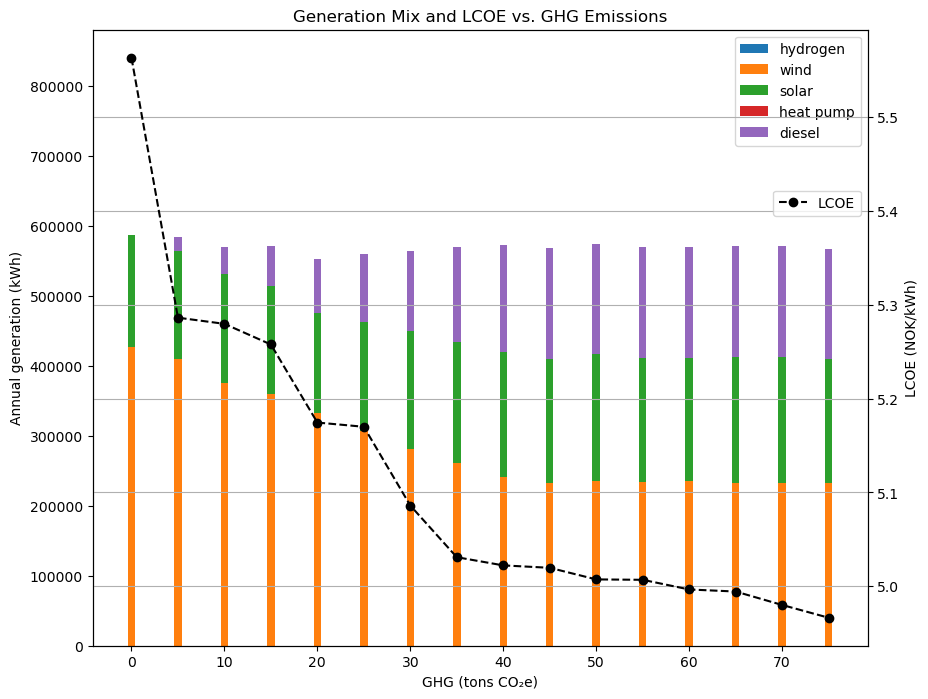

In [10]:
overall_lcoe.sort(reverse=True)
emission_levels.sort()

generation_df.sort_index(inplace=True)
print(generation_df)
fig, ax1 = plt.subplots(figsize=(10, 8))


bottom = pd.Series([0] * len(generation_df),index=generation_df.index)

for carrier in generation_df.columns:
    ax1.bar(generation_df.index, generation_df[carrier], bottom=bottom, label=carrier)
    bottom += generation_df[carrier]
ax1.set_ylim(0, 800000 * 1.1)
ax2 = ax1.twinx()
ax2.plot(emission_levels, overall_lcoe, 'k--', marker='o', label='LCOE', color='black')
ax1.set_xlabel('GHG (tons CO₂e)')
ax1.set_ylabel('Annual generation (kWh)')
ax2.set_ylabel('LCOE (NOK/kWh)')
ax1.legend(loc='upper right')
ax2.legend(loc='upper right',bbox_to_anchor=(1.0, 0.75))
plt.title('Generation Mix and LCOE vs. GHG Emissions')
plt.grid(True)
plt.show()
